# Project Title :

## Book Market Analysis Using Web Scraping and Data Analytics

# Objective :

The objective of this project is to collect book data from Books to Scrape website using web scraping techniques and analyze pricing patterns, category-wise trends, ratings, and stock availability to generate meaningful business insights.

# **Web Scraping :**

In [1]:
import requests    #requests - Sends HTTP requests to the website.
from bs4 import BeautifulSoup   #BeautifulSoup - Parses HTML content.
import pandas as pd    # pandas - Stores scraped data in a DataFrame.

In [2]:
Book_names = []
Prices = []
Ratings = []
Availability = []

In [3]:
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/149.0.0.0 Safari/537.36",
    "Accept-Language": "en-US,en;q=0.9",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8"
}

for page in range(1, 51):

    url = f"https://books.toscrape.com/catalogue/page-{page}.html"

    response = requests.get(url, headers=headers)

    soup = BeautifulSoup(response.text, "html.parser")

    books = soup.find_all("article", class_="product_pod")
    for book in books:

        Book_names.append(
            book.h3.a["title"]
        )

        Prices.append(
            book.find(
                "p",
                class_="price_color"
            ).text
        )

        Ratings.append(
            book.find(
                "p",
                class_="star-rating"
            )["class"][1]
        )

        Availability.append(
            book.find(
                "p",
                class_="instock availability"
            ).text.strip()
        )

In [4]:
print("Book Names :", Book_names)
print("Prices :", Prices)
print("Ratings :", Ratings)
print("Availability :", Availability)

Book Names : ['A Light in the Attic', 'Tipping the Velvet', 'Soumission', 'Sharp Objects', 'Sapiens: A Brief History of Humankind', 'The Requiem Red', 'The Dirty Little Secrets of Getting Your Dream Job', 'The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull', 'The Boys in the Boat: Nine Americans and Their Epic Quest for Gold at the 1936 Berlin Olympics', 'The Black Maria', 'Starving Hearts (Triangular Trade Trilogy, #1)', "Shakespeare's Sonnets", 'Set Me Free', "Scott Pilgrim's Precious Little Life (Scott Pilgrim #1)", 'Rip it Up and Start Again', 'Our Band Could Be Your Life: Scenes from the American Indie Underground, 1981-1991', 'Olio', 'Mesaerion: The Best Science Fiction Stories 1800-1849', 'Libertarianism for Beginners', "It's Only the Himalayas", 'In Her Wake', 'How Music Works', 'Foolproof Preserving: A Guide to Small Batch Jams, Jellies, Pickles, Condiments, and More: A Foolproof Guide to Making Small Batch Jams, Jellies, Pickles, Condiment

In [5]:
print("Book Names :", len(Book_names))
print("Prices :", len(Prices))
print("Ratings :", len(Ratings))
print("Availability :", len(Availability))

Book Names : 1000
Prices : 1000
Ratings : 1000
Availability : 1000


In [6]:
min_len = min(
    len(Book_names),
    len(Prices),
    len(Ratings),
    len(Availability)
)

df = pd.DataFrame({
    "Book Name": Book_names[:min_len],
    "Price": Prices[:min_len],
    "Rating": Ratings[:min_len],
    "Availability": Availability[:min_len]
})

In [7]:
df.shape

(1000, 4)

In [8]:
df.head()

,Book Name,Price,Rating,Availability
0,A Light in the Attic,Â£51.77,Three,In stock
1,Tipping the Velvet,Â£53.74,One,In stock
2,Soumission,Â£50.10,One,In stock
3,Sharp Objects,Â£47.82,Four,In stock
4,Sapiens: A Brief History of Humankind,Â£54.23,Five,In stock


In [9]:
df.to_csv("books_to_scrape_dataset.csv", index=False)

print("DataFrame saved Successfully")

DataFrame saved Successfully


In [10]:
saved_df = pd.read_csv("books_to_scrape_dataset.csv")

saved_df.head()

,Book Name,Price,Rating,Availability
0,A Light in the Attic,Â£51.77,Three,In stock
1,Tipping the Velvet,Â£53.74,One,In stock
2,Soumission,Â£50.10,One,In stock
3,Sharp Objects,Â£47.82,Four,In stock
4,Sapiens: A Brief History of Humankind,Â£54.23,Five,In stock


# **Exploratory Data Analysis (EDA) :**

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_csv("/content/books_to_scrape_dataset.csv")

df.head()

,Book Name,Price,Rating,Availability
0,A Light in the Attic,Â£51.77,Three,In stock
1,Tipping the Velvet,Â£53.74,One,In stock
2,Soumission,Â£50.10,One,In stock
3,Sharp Objects,Â£47.82,Four,In stock
4,Sapiens: A Brief History of Humankind,Â£54.23,Five,In stock


# **Data Understanding :**

In [13]:
print("Shape of Dataset:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe(include="all"))

Shape of Dataset: (1000, 4)

Columns:
Index(['Book Name', 'Price', 'Rating', 'Availability'], dtype='object')

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Book Name     1000 non-null   object
 1   Price         1000 non-null   object
 2   Rating        1000 non-null   object
 3   Availability  1000 non-null   object
dtypes: object(4)
memory usage: 31.4+ KB
None

Missing Values:
Book Name       0
Price           0
Rating          0
Availability    0
dtype: int64

Statistical Summary:
                     Book Name    Price Rating Availability
count                     1000     1000   1000         1000
unique                     999      903      5            1
top     The Star-Touched Queen  Â£44.18    One     In stock
freq                         2        3    226         1000


In [14]:
# checking for duplicate records

df.duplicated().sum()

# we can see that there are no duplicate records

np.int64(0)

# **Data Cleaning :**

In [15]:
# checking dataset

df.head()

,Book Name,Price,Rating,Availability
0,A Light in the Attic,Â£51.77,Three,In stock
1,Tipping the Velvet,Â£53.74,One,In stock
2,Soumission,Â£50.10,One,In stock
3,Sharp Objects,Â£47.82,Four,In stock
4,Sapiens: A Brief History of Humankind,Â£54.23,Five,In stock


In [16]:
# Cleaning Price Column

df["Price"] = df["Price"].str.replace("Â£", "", regex=False)

df["Price"] = pd.to_numeric(df["Price"])

In [17]:
df["Price"].head()

,Price
0,51.77
1,53.74
2,50.10
3,47.82
4,54.23


In [18]:
# cleaning rating column

df["Rating"].unique()

array(['Three', 'One', 'Four', 'Five', 'Two'], dtype=object)

In [19]:
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["Rating"] = df["Rating"].map(rating_map)

In [20]:
df["Rating"].unique()

array([3, 1, 4, 5, 2])

In [21]:
# Checking Data Types Again

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Book Name     1000 non-null   object 
 1   Price         1000 non-null   float64
 2   Rating        1000 non-null   int64  
 3   Availability  1000 non-null   object 
dtypes: float64(1), int64(1), object(2)
memory usage: 31.4+ KB


In [22]:
df.isnull().sum()

,0
Book Name,0
Price,0
Rating,0
Availability,0


In [23]:
# Saving Cleaned Dataset

df.to_csv("books_cleaned.csv", index=False)
print("Dataset saved successfully")

Dataset saved successfully


In [24]:
df = pd.read_csv("/content/books_cleaned.csv")

df.head()

,Book Name,Price,Rating,Availability
0,A Light in the Attic,51.77,3,In stock
1,Tipping the Velvet,53.74,1,In stock
2,Soumission,50.10,1,In stock
3,Sharp Objects,47.82,4,In stock
4,Sapiens: A Brief History of Humankind,54.23,5,In stock


# **Exploratory Data Analysis (EDA) :**

**Objective 1: Price Analysis of Books**

In [25]:
# Summary Statistics of Price

df["Price"].describe()

,Price
count,1000.00000
mean,35.07035
std,14.44669
min,10.00000
25%,22.10750
50%,35.98000
75%,47.45750
max,59.99000


In [26]:
# Most Expensive Books

df.sort_values(
    by="Price",
    ascending=False
).head(10)

,Book Name,Price,Rating,Availability
648,The Perfect Play (Play by Play #1),59.99,3,In stock
617,Last One Home (New Beginnings #1),59.98,3,In stock
860,Civilization and Its Discontents,59.95,2,In stock
560,The Barefoot Contessa Cookbook,59.92,5,In stock
366,The Diary of a Young Girl,59.90,3,In stock
657,The Bone Hunters (Lexy Vaughan & Steven Macaul...,59.71,3,In stock
133,Thomas Jefferson and the Tripoli Pirates: The ...,59.64,1,In stock
387,Boar Island (Anna Pigeon #19),59.48,3,In stock
549,The Man Who Mistook His Wife for a Hat and Oth...,59.45,4,In stock
393,The Improbability of Love,59.45,1,In stock


In [27]:
# Least Expensive Books

df.sort_values(
    by="Price",
    ascending=True
).head(10)

,Book Name,Price,Rating,Availability
638,An Abundance of Katherines,10.00,5,In stock
501,The Origin of Species,10.01,4,In stock
716,The Tipping Point: How Little Things Can Make ...,10.02,2,In stock
84,Patience,10.16,3,In stock
302,Greek Mythic History,10.23,5,In stock
558,The Fellowship of the Ring (The Lord of the Ri...,10.27,2,In stock
479,History of Beauty,10.29,4,In stock
242,The Lucifer Effect: Understanding How Good Peo...,10.40,1,In stock
434,"NaNo What Now? Finding your editing process, r...",10.41,4,In stock
274,Pet Sematary,10.56,3,In stock


In [28]:
# Price Distribution

df["Price"].value_counts().head()

,count
Price,
44.18,3
37.34,3
39.24,3
16.28,3
27.88,3


**Objective 2: Rating Analysis**

In [29]:
# Unique Ratings

df["Rating"].unique()

array([3, 1, 4, 5, 2])

In [30]:
# Count of books by rating

df["Rating"].value_counts()

,count
Rating,
1,226
3,203
5,196
2,196
4,179


In [31]:
# Rating Percentage Distribution

round(
    df["Rating"].value_counts(normalize=True)*100,
    2
)

,proportion
Rating,
1,22.6
3,20.3
5,19.6
2,19.6
4,17.9


In [32]:
# Average Price by Rating

df.groupby("Rating")["Price"].mean()

,Price
Rating,
1,34.561195
2,34.810918
3,34.692020
4,36.093296
5,35.374490


In [33]:
# Number of Books per Rating

df.groupby("Rating").size()

,0
Rating,
1,226
2,196
3,203
4,179
5,196


**Objective 3: Availability Analysis**

In [34]:
# Availability Counts

df["Availability"].value_counts()

,count
Availability,
In stock,1000


In [35]:
# Availability Percentage

round(
    df["Availability"].value_counts(normalize=True)*100,
    2
)

,proportion
Availability,
In stock,100.0


In [36]:
# Average Price by Availability

df.groupby("Availability")["Price"].mean()

,Price
Availability,
In stock,35.07035


# **Data Visualization**

**Univariate Analysis :**

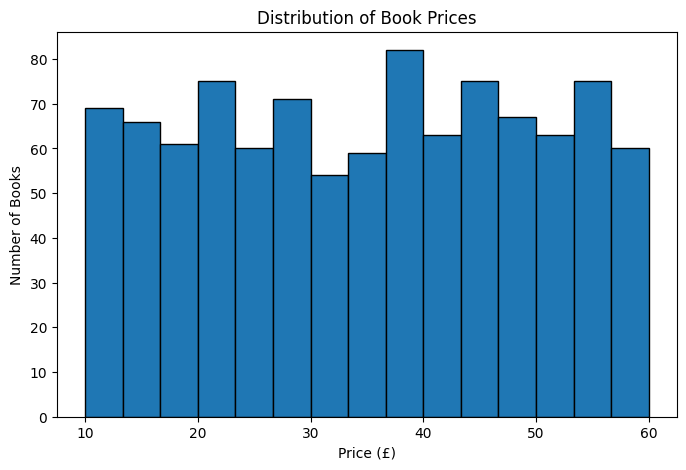

In [37]:
# Price Distribution

plt.figure(figsize=(8,5))

plt.hist(
    df["Price"],
    bins=15,
    edgecolor="black"
)

plt.xlabel("Price (£)")
plt.ylabel("Number of Books")
plt.title("Distribution of Book Prices")

plt.show()

## Observation : Book prices are evenly distributed between £10 and £60, indicating a balanced mix of affordable and premium-priced books.

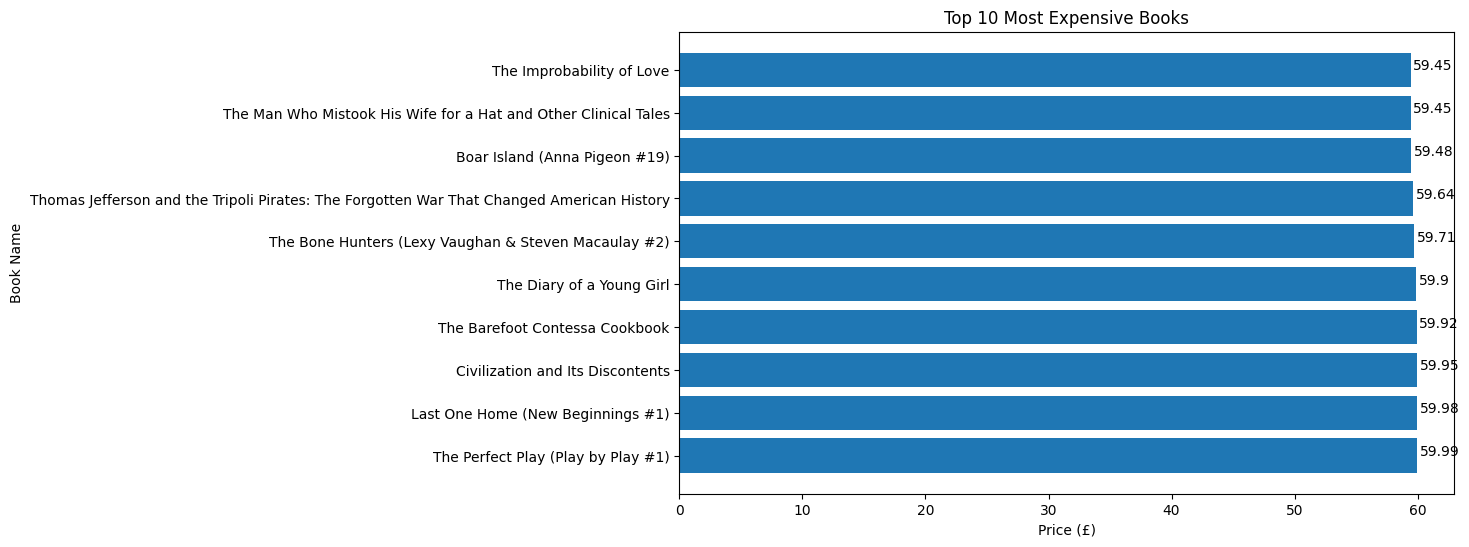

In [39]:
# Top 10 most expensive books

top_10 = df.sort_values(by="Price", ascending=False).head(10)

plt.figure(figsize=(10,6))

bars = plt.barh(
    top_10["Book Name"],
    top_10["Price"]
)

for bar in bars:
    plt.text(
        bar.get_width()+0.2,
        bar.get_y()+bar.get_height()/2,
        round(bar.get_width(),2)
    )

plt.xlabel("Price (£)")
plt.ylabel("Book Name")
plt.title("Top 10 Most Expensive Books")

plt.show()

## Observation : The top 10 most expensive books are priced within a very narrow range near £60. This indicates a consistent pricing strategy for premium books, with no significant price outliers.

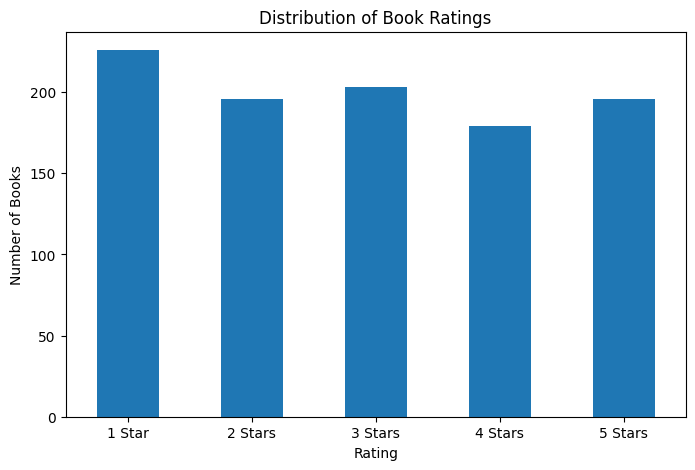

In [40]:
# Rating Distribution

rating_counts = df["Rating"].value_counts().sort_index()

plt.figure(figsize=(8,5))

rating_counts.plot(kind="bar")

plt.xticks(
    range(5),
    ["1 Star", "2 Stars", "3 Stars", "4 Stars", "5 Stars"],
    rotation=0
)

plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.title("Distribution of Book Ratings")

plt.show()

# Observation : Book ratings are fairly evenly distributed, with 1-star books being the most common and 4-star books being the least common.

**Bivariate Analysis :**

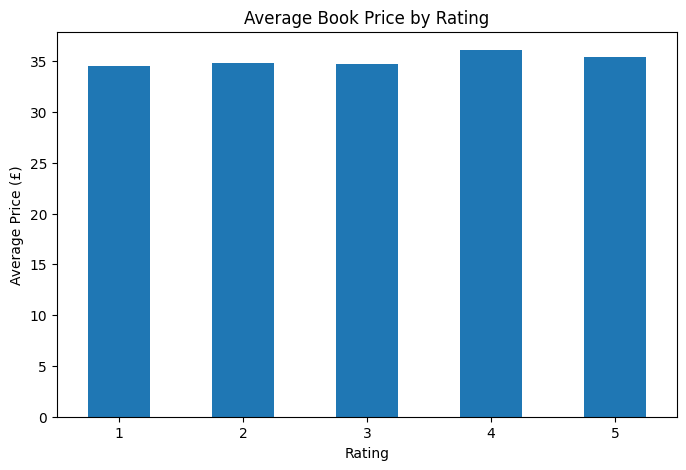

In [41]:
# Average Price by Rating

avg_price_rating = df.groupby("Rating")["Price"].mean()

plt.figure(figsize=(8,5))

avg_price_rating.plot(kind="bar")

plt.xlabel("Rating")
plt.ylabel("Average Price (£)")
plt.title("Average Book Price by Rating")

plt.xticks(rotation=0)

plt.show()

## Observation : The average price remains relatively consistent across all rating categories. This suggests that book prices are not strongly influenced by ratings, and both highly-rated and low-rated books are available at similar price levels.

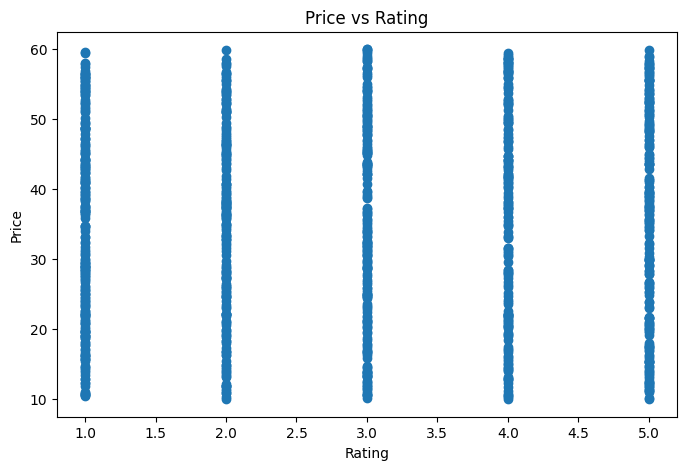

In [42]:
# Scatter Plot: Price vs Rating

plt.figure(figsize=(8,5))

plt.scatter(
    df["Rating"],
    df["Price"]
)

plt.xlabel("Rating")
plt.ylabel("Price")
plt.title("Price vs Rating")

plt.show()

## Observation : The scatter plot shows no strong relationship between book ratings and prices. Books across all rating categories are available in both lower and higher price ranges. This suggests that book pricing is not significantly influenced by ratings in the dataset.

<Figure size 800x500 with 0 Axes>

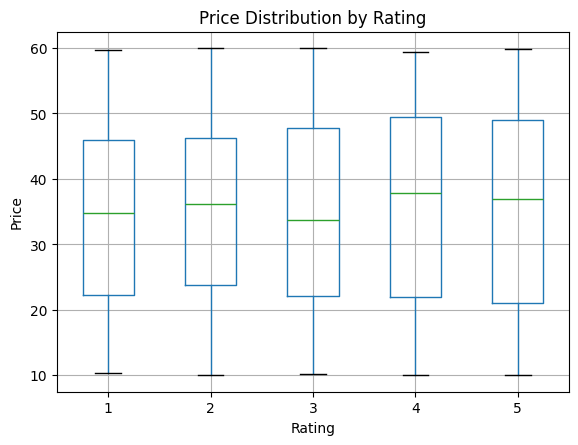

In [43]:
# Box Plot: Price by Rating

plt.figure(figsize=(8,5))

df.boxplot(
    column="Price",
    by="Rating"
)

plt.title("Price Distribution by Rating")
plt.suptitle("")

plt.xlabel("Rating")
plt.ylabel("Price")

plt.show()

## Observation : Book prices remain relatively consistent across all rating categories, suggesting no strong relationship between ratings and price.

**Multivariate Analysis :**

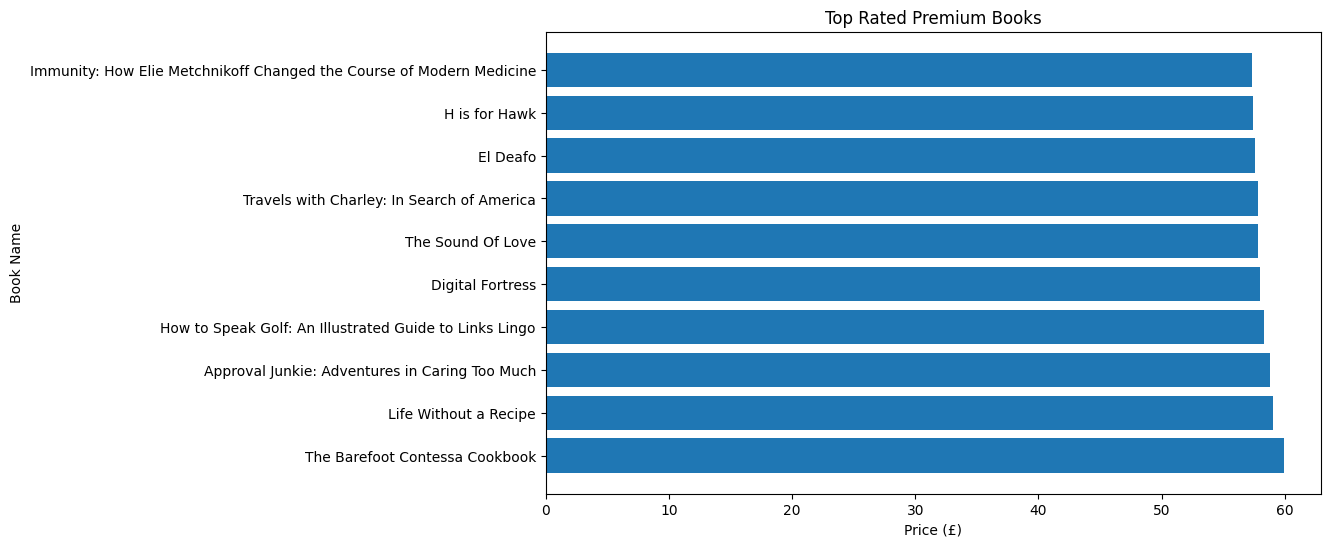

In [44]:
## Top 10 Highest Rated Expensive Books

top_books = df.sort_values(
    by=["Rating", "Price"],
    ascending=[False, False]
).head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_books["Book Name"],
    top_books["Price"]
)

plt.xlabel("Price (£)")
plt.ylabel("Book Name")
plt.title("Top Rated Premium Books")

plt.show()

## Observation : The top-rated books are priced within a narrow premium range of approximately £58–£60. This indicates that highly-rated books tend to be positioned in the upper price segment. However, the small difference in prices suggests a consistent pricing strategy among premium-quality books.

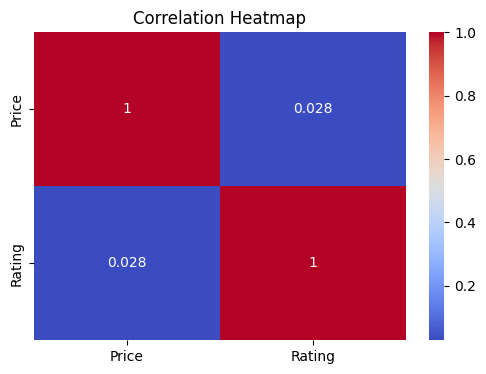

In [45]:
# Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    df[["Price","Rating"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

## Observation : The correlation heatmap shows a very weak positive correlation (0.028) between book price and rating. This indicates that book ratings have almost no influence on pricing. Highly-rated books are not necessarily more expensive, and lower-rated books can also be found in premium price ranges.

# **Business Insights :**

- Book prices are distributed across a wide range (£10–£60), providing options for both budget-conscious and premium customers.

- The average price of books falls within a moderate range, indicating balanced pricing across the marketplace.

- Premium-priced books are clustered around £60, suggesting a consistent upper pricing threshold.

- Rating distribution is relatively balanced across all rating categories, indicating diversity in customer preferences and book quality.

- Highly-rated books are generally found in the premium price segment, suggesting a relationship between perceived quality and pricing.

- No extreme price outliers were observed, indicating stable and controlled pricing throughout the catalog.

# **Recommendations :**

- Publishers can maintain a balanced pricing strategy as customers have access to books across multiple price ranges.

- Premium books should continue to be positioned in the £55–£60 range, where customers appear willing to pay for highly-rated content.

- Marketing efforts can focus on highly-rated books to increase visibility and sales.

- Further category-level analysis could help identify the most profitable book genres and customer interests.

# **Conclusion :**

- In this project, I collected book data from the Books to Scrape website using web scraping techniques with Python, Requests, and BeautifulSoup. After extracting the data, I performed data cleaning and created a structured dataset containing information such as book name, price, rating, and availability.

- I then carried out exploratory data analysis and visualizations to understand the pricing patterns, rating distribution, and availability of books. From the analysis, I found that book prices are spread across different price ranges and that ratings are fairly balanced among books. I also observed that there is no strong relationship between book price and rating, which was confirmed through correlation analysis.

- Overall, this project helped me gain practical experience in web scraping, data cleaning, data analysis, and data visualization. It gave me a complete understanding of how to convert raw web data into meaningful insights that can support decision-making.